# Homework06

Exercises to practice pandas, data analysis and regression

## Goals

- Understand the effects of pre-processing data
- Get familiar with the ML flow: encode -> normalize -> train -> evaluate
- Understand the difference between regression and classification tasks
- Build intuition for different regression models

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [1]:
!curl -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!curl -sL https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py -o data_utils.py


  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor

from data_utils import object_from_json_url
from data_utils import regression_error

### Load Dataset

Let's load up the full [ANSUR](https://www.openlab.psu.edu/ansur2/) dataset that we looked at briefly in [Week 02](https://github.com/DM-GY-9103-2024F-H/WK02).

This is the dataset that has anthropometric information about U.S. Army personnel.

#### WARNING

Like we mentioned in class, this dataset is being used for these exercises due to the level of detail in the dataset and the rigorous process that was used in collecting the data.

This is a very specific dataset and should not be used to draw general conclusions about people, bodies, or anything else that is not related to the distribution of physical features of U.S. Army personnel.

In [3]:
# Load Dataset
ANSUR_FILE = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/main/datasets/json/ansur.json"
ansur_data = object_from_json_url(ANSUR_FILE)

# Look at first 2 records
ansur_data[:2]

[{'age': 18,
  'gender': 'F',
  'height': 66,
  'weight': 135,
  'span': 1699,
  'stature': 1645,
  'ear': {'breadth': 30, 'length': 61, 'protrusion': 20},
  'foot': {'breadth': 97, 'length': 243},
  'hand': {'breadth': 78, 'length': 182, 'palm': 108},
  'head': {'height': 243, 'circumference': 557}},
 {'age': 30,
  'gender': 'M',
  'height': 68,
  'weight': 207,
  'span': 1749,
  'stature': 1715,
  'ear': {'breadth': 35, 'length': 63, 'protrusion': 17},
  'foot': {'breadth': 100, 'length': 252},
  'hand': {'breadth': 87, 'length': 184, 'palm': 114},
  'head': {'height': 238, 'circumference': 560}}]

#### Nested data

This is that *nested* dataset from Week 02.

# 🤔

Let's load it into a `DataFrame` to see what happens.

In [4]:
# Read into DataFrame
ansur_df = pd.DataFrame.from_records(ansur_data)
ansur_df.head()

,age,gender,height,weight,span,stature,ear,foot,hand,head
0,18,F,66,135,1699,1645,"{'breadth': 30, 'length': 61, 'protrusion': 20}","{'breadth': 97, 'length': 243}","{'breadth': 78, 'length': 182, 'palm': 108}","{'height': 243, 'circumference': 557}"
1,30,M,68,207,1749,1715,"{'breadth': 35, 'length': 63, 'protrusion': 17}","{'breadth': 100, 'length': 252}","{'breadth': 87, 'length': 184, 'palm': 114}","{'height': 238, 'circumference': 560}"
2,27,M,67,121,1684,1657,"{'breadth': 36, 'length': 59, 'protrusion': 24}","{'breadth': 92, 'length': 251}","{'breadth': 84, 'length': 180, 'palm': 103}","{'height': 239, 'circumference': 516}"
3,20,M,73,185,1878,1828,"{'breadth': 36, 'length': 60, 'protrusion': 21}","{'breadth': 104, 'length': 280}","{'breadth': 95, 'length': 201, 'palm': 124}","{'height': 270, 'circumference': 582}"
4,33,M,76,150,1977,1883,"{'breadth': 39, 'length': 65, 'protrusion': 27}","{'breadth': 101, 'length': 271}","{'breadth': 90, 'length': 194, 'palm': 113}","{'height': 254, 'circumference': 559}"



# 😓🙄

That didn't work too well. We ended up with objects in our columns.

Luckily, our `DataFrame` library has a function called [`json_normalize()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.json_normalize.html) that can help.

In [5]:
# Read into DataFrame
ansur_df = pd.json_normalize(ansur_data)
ansur_df.head()

,age,gender,height,weight,span,stature,ear.breadth,ear.length,ear.protrusion,foot.breadth,foot.length,hand.breadth,hand.length,hand.palm,head.height,head.circumference
0,18,F,66,135,1699,1645,30,61,20,97,243,78,182,108,243,557
1,30,M,68,207,1749,1715,35,63,17,100,252,87,184,114,238,560
2,27,M,67,121,1684,1657,36,59,24,92,251,84,180,103,239,516
3,20,M,73,185,1878,1828,36,60,21,104,280,95,201,124,270,582
4,33,M,76,150,1977,1883,39,65,27,101,271,90,194,113,254,559


Much better. `DataFrames` are magic.

#### Data Exploration

Before we start creating models, let's do a little bit of data analysis and get a feeling for the shapes, distributions and relationships of our data.

1. Print `min`, `max` and `average` values for all of the features.
2. Print `covariance` tables for `age`, `ear.length` and `head.circumference`.
3. Plot `age`, `ear.length` and `head.circumference` versus the $1$ *feature* that is most correlated to each of them.

Don't forget to *encode* and *normalize* the data.

age                  min=17  max=58  avg=29.74535714285714
gender               min=0.0  max=1.0  avg=0.6726785714285715
height               min=56  max=94  avg=68.24732142857142
weight               min=0  max=321  avg=174.55839285714285
span                 min=1323  max=2121  avg=1763.703392857143
stature              min=1409  max=1993  avg=1714.265357142857
ear.breadth          min=25  max=46  avg=35.128928571428574
ear.length           min=46  max=81  avg=62.637142857142855
ear.protrusion       min=13  max=34  avg=22.266785714285714
foot.breadth         min=77  max=126  avg=98.85089285714285
foot.length          min=198  max=323  avg=262.9919642857143
hand.breadth         min=67  max=105  avg=84.93696428571428
hand.length          min=145  max=239  avg=189.26017857142858
hand.palm            min=88  max=140  avg=113.91964285714286
head.height          min=206  max=295  avg=249.17089285714286
head.circumference   min=502  max=635  avg=570.0628571428572
                         ag

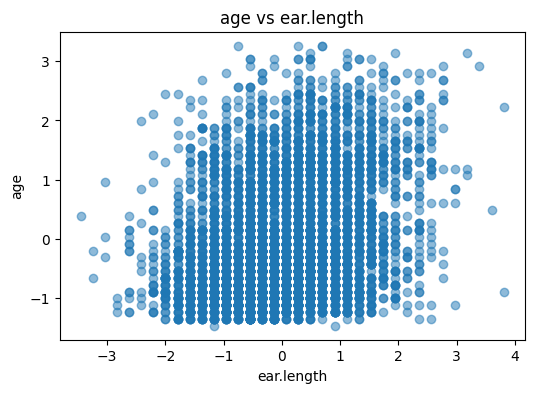

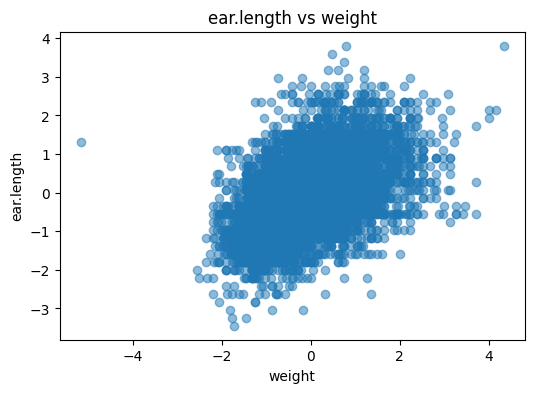

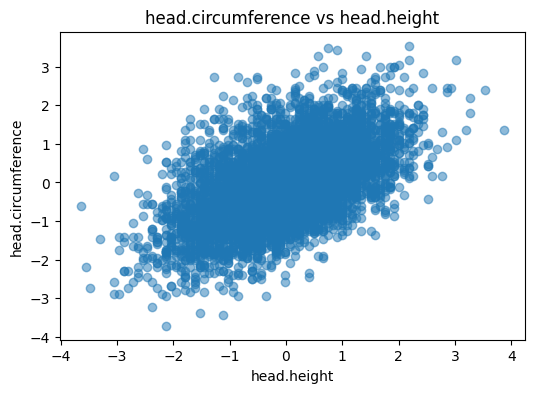

In [6]:
# Work on Data Exploration here

### Encode non-numerical features
ansur_encoder = OrdinalEncoder()
ansur_df[['gender']] = ansur_encoder.fit_transform(ansur_df[['gender']])
ansur_df.head()

## 1. Print min, max, avg
for col in ansur_df.columns:
    print(f"{col:20} min={ansur_df[col].min()}  max={ansur_df[col].max()}  avg={ansur_df[col].mean()}")

### Normalize all data
ansur_scaler = StandardScaler()
ansur_scaled = ansur_scaler.fit_transform(ansur_df)
ansur_df = pd.DataFrame(ansur_scaled, columns=ansur_df.columns)

## 2. Print Covariances
print(ansur_df[["age", "ear.length", "head.circumference"]].cov())

## 3. Plot features most correlated to age, ear length and head circumference

targets = ["age", "ear.length", "head.circumference"]
correlations = ansur_df.corr()

for target in targets:
    best_feature = correlations[target].drop(target).abs().sort_values(ascending=False).index[0]

    plt.figure(figsize=(6, 4))
    plt.scatter(ansur_df[best_feature], ansur_df[target], alpha=0.5)
    plt.xlabel(best_feature)
    plt.ylabel(target)
    plt.title(f"{target} vs {best_feature}")
    plt.show()



### Interpretation

<span style="color:hotpink;">
Does anything stand out about these graphs? Or the correlations?<br>
Are correlations symmetric? Does the feature most correlated to ear length also have ear length as its most correlated pair?
</span>

<span style="color:hotpink;">According to my understanding I thought using the corelation matrix was the best way to find out which feature corelated the best with out target features.

Age vs Ear Length - They have a very loose corelation - its more random I feel. It has not pattern.
Weight vs Ear Length - Over here surpsingly there is a strong corelation which has more of a positive trend. 
Head Circ vs Head Height - I am not sure if i should have kept the ear length over here but according to the correlation matrix head height was better. Here again there is a nice positive strong correlation. 

Overall I feel the last two graphs are sort of symmetric but again I dont think we are using the right features as of now to find out the corelations and data trends. Also the most corelated with ear length is Weight and not age   </span>

### Regression

Now, we want to create a regression model to predict `head.circumference` from the data.

From our [Week 06](https://github.com/PSAM-5020-2026S-A/WK06) notebook, we can create a regression model by following these steps:

1. Load dataset (done! 🎉)
2. Encode label features as numbers (done! ⚡️)
3. Normalize the data (done! 🍾)
4. Separate the outcome variable and the input features
5. Create a regression model using all features
6. Run model on training data and measure error
7. Plot predictions and interpret results
8. Run model on test data, measure error, plot predictions, interpret results

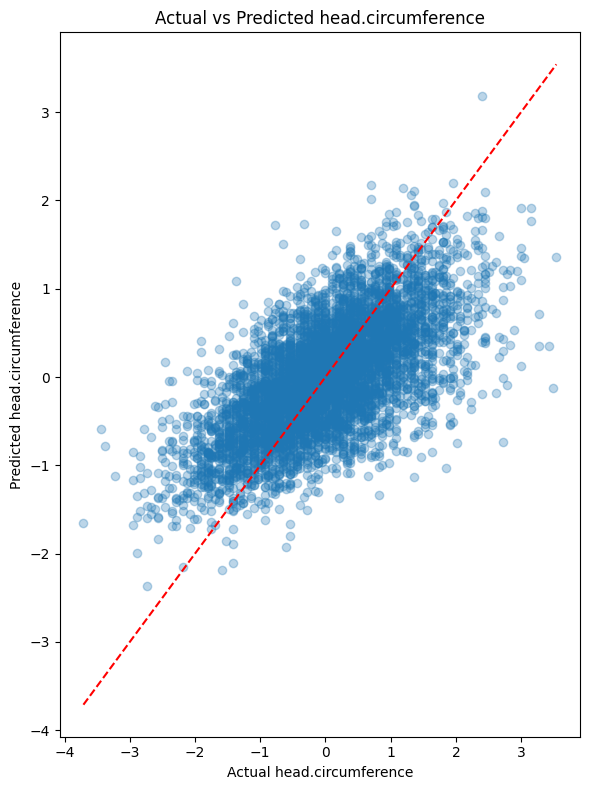

In [7]:
# Work on Regression Model here

## Separate outcome variable and input features
y_prediction = ansur_df['head.circumference']
x_input = ansur_df.drop(columns=['head.circumference'])

## Create a regression model
model = LinearRegression()
model.fit(x_input, y_prediction)

## Measure error on training data
y_pred_train = model.predict(x_input)
error = regression_error(y_prediction, y_pred_train)

## Plot predictions and interpret results

plt.figure(figsize=(6,8))
plt.scatter(y_prediction, y_pred_train, alpha=0.3)
plt.plot([y_prediction.min(), y_prediction.max()], [y_prediction.min(), y_prediction.max()], 'r--')
plt.xlabel("Actual head.circumference")
plt.ylabel("Predicted head.circumference")
plt.title("Actual vs Predicted head.circumference")
plt.tight_layout()
plt.show()

In [8]:
## Load Test Data
ANSUR_TEST_FILE = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/main/datasets/json/ansur-test.json"

ansur_test_data = object_from_json_url(ANSUR_TEST_FILE)
ansur_test_df = pd.json_normalize(ansur_test_data)

ansur_test_encoded_df = ansur_test_df.copy()

g_vals = ansur_encoder.transform(ansur_test_df[["gender"]])
ansur_test_encoded_df[["gender"]] = g_vals

ansur_test_scaled_df = ansur_scaler.transform(ansur_test_encoded_df)

Test error: 0.7891115826821988


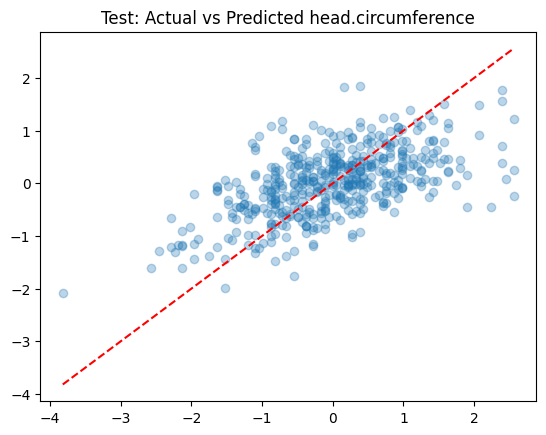

In [9]:
## Run model on test data
X_test = pd.DataFrame(ansur_test_scaled_df, columns=ansur_test_encoded_df.columns).drop(columns=['head.circumference'])
y_test_actual = pd.DataFrame(ansur_test_scaled_df, columns=ansur_test_encoded_df.columns)['head.circumference']

## Measure error on test data
y_test_predicted = model.predict(X_test)
print(f"Test error: {regression_error(y_test_actual, y_test_predicted)}")

## Plot predictions and interpret results
plt.scatter(y_test_actual, y_test_predicted, alpha=0.3)
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--')
plt.title("Test: Actual vs Predicted head.circumference")
plt.show()


### Interpretation

<span style="color:hotpink;">
How well does your model perform?<br>
I think the model has done reasonably well. The points follow the red line with a positive trend. The test error is around 0.79 which I feel is pretty decent?
How could you improve it?<br>
Collect more data at extremes? Use features with very strong corelation. 

Are there ranges of circumferences that don't get predicted well?
Yes. The extremes. At the very low end and the very high end. 
</span>

<span style="color:hotpink;">EDIT THIS CELL WITH ANSWER</span>